In [5]:
import os
import sys 

import numpy as np
import random
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
# collect the full path to this script 
parent_directory = os.path.dirname(os.getcwd())
output_directory = os.path.join(parent_directory, 'notebooks', 'output_csv')
sys.path.append(parent_directory)

# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)

In [6]:

csv_path = os.path.join(output_directory, 'threshold_analysis_full_dataframe.csv')

df = pd.read_csv(csv_path)
optimal_thresholds = df.groupby('emdb_id')['optimal_threshold'].first().to_dict()
optimal_f1_scores = df.groupby('emdb_id')['optimal_f1_score'].first().to_dict()
threshold_values = df['threshold'].unique()
f1_values_with_threshold = df.groupby('emdb_id')['f1_score'].apply(list).to_dict()
emdb_ids = df['emdb_id'].unique()

Text(0, 0.5, 'F1 score')

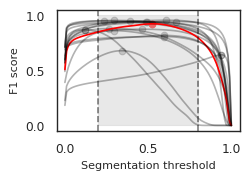

In [7]:
figsize_mm = (60, 40)
figsize = (figsize_mm[0] / 25.4, figsize_mm[1] / 25.4)  # Convert mm to inches
fig, ax = plt.subplots(figsize=figsize)
sns.set_theme(context="paper")
sns.set_style("white")
for i, emdb_id in enumerate(emdb_ids):
    f1_values = np.array(f1_values_with_threshold[emdb_id])
    optimal_threshold = optimal_thresholds[int(emdb_id)]
    optimal_f1_score = optimal_f1_scores[int(emdb_id)]
    
    if emdb_id == 8702:
        ax.plot(threshold_values, f1_values, color="red", alpha=1)
        ax.scatter(optimal_threshold, optimal_f1_score, color="red")
    else:
        ax.plot(threshold_values, f1_values, color="black", alpha=0.3)
        ax.scatter(optimal_threshold, optimal_f1_score, color="black", alpha=0.3)

x_1 = 0.2 
x_2 = 0.8
ax.axvline(x=x_1, color='black', linestyle='--', alpha=0.5)
ax.axvline(x=x_2, color='black', linestyle='--', alpha=0.5)
# shade the area between the two vertical lines with light cream
ax.fill_betweenx(y=[0, 1], x1=x_1, x2=x_2, color='lightgrey', alpha=0.5)
    
ax.set_xlabel("Segmentation threshold", fontsize=8)
ax.set_ylabel("F1 score", fontsize=8)